# Building Distributions

The purpose of this notebook is to build some canonical distributions used for convergence testing. 
These include
- normal distribution
- geometric distribution
- binomial distribution


In [1]:
import time

import numpy as np
import pandas as pd

import matplotlib.pyplot as plt
from tabulate import tabulate



We begin by building a normal distribution 
$$
 X \sim N(0, 2^2)
$$

Where we want to estimate this quantity 
$$
E(X^2)
$$

using $N$ samples $X_1, \ldots, X_N$ and estimator:

$$
\mu_N  = \frac{1}{N} \sum_{i=1}^N X_i^2
$$

**The theory**

Here is to see that the standard error of this MC method estimator is proportional to the inverse square root of the number of samples taken from the distribution.

\begin{align*}
    SE \propto \frac{1}{\sqrt{N}}
\end{align*}



(array([1., 0., 1., 0., 3., 0., 2., 1., 1., 1.]),
 array([-5.92905768, -4.85206891, -3.77508014, -2.69809137, -1.6211026 ,
        -0.54411383,  0.53287494,  1.60986371,  2.68685248,  3.76384125,
         4.84083002]),
 <BarContainer object of 10 artists>)

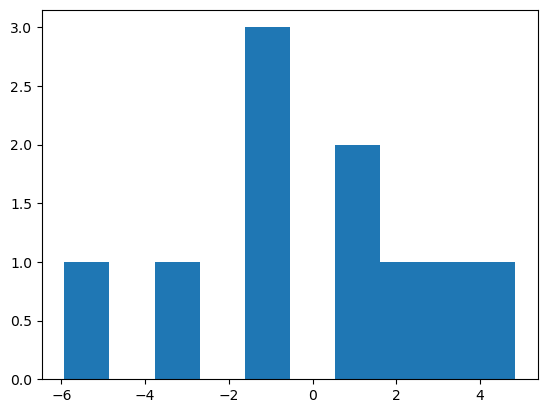

In [ ]:
# building a distribution:

# seeding
rng = np.random.default_rng(seed=42)

# get an array of norm rnds
# generate N samples:
N = 10
sigma = 2.0
true_mean = 0.0
X = rng.normal(loc=true_mean, scale=sigma, size=N)

# make normal distro. check with plot
plt.hist(rnd_array)


# Build an Estimator


We proceed to compute the estimator and compare its performance as $N$ (the number of points sampled) scales.
$$
\mu_N  = \frac{1}{N} \sum_{i=1}^N X_i^2.
$$

Moreover, we will not simply use this estimate directly, but we will take **multiple repeated** samples at the same sample size before increasing the sample size. This means we will end up with a collection of samples like this:

$$
    \mathbb{U} = \{ \{ \vec{u}^i_{N_1}\}, \{ \vec{u}^i_{N_2} \} , \{ \vec{u}^i_{N_3} \} , \ldots,  \{ \vec{u}^i_{N_k} \} \},
$$

where  $\{\vec{u}^i_{N_1}\}$ is the set of samples of size $N_1$ and $N_1 < N_2 <\cdots < N_k$, and $i = 1, 2, ..., I$ is fixed, i.e., we take the same redraw size even as the sample size changes.

We can then form the estimates:

\begin{align*}
    \mathbb{\Mu} = \{ 
        \{ \mu^i_{N_1} =  \frac{(\vec{u}^i_{N_1} \cdot \vec{u}^i_{N_1})}{ N_1} \}, 
        \{ \mu^i_{N_2} =  \frac{(\vec{u}^i_{N_2} \cdot \vec{u}^i_{N_2})}{ N_2} \},
        \ldots,
        \{ \mu^i_{N_k} =  \frac{(\vec{u}^i_{N_k} \cdot \vec{u}^i_{N_k})}{ N_k} \}
    \}.
\end{align*}

Instead of comparing just one of the estimates $\mu^i_{N_i} $ versus another $\mu^i_{N_j}$, we will instead compute the **mean** of the samples at that size so that: 

\begin{align*}
    \mathbb{\bar{U}} = \{ 
        \bar{\mu}_{N_1}, \bar{\mu}_{N_2}, \ldots, \bar{\mu}_{N_k}
    \}
\end{align*}

These values are less sensitive to the variability in the random draw. With this we can compare the estimator, the standard deviation, and the RMSE:

\begin{align*}
    i \text{-th estimator: } \mu^i_N =  \frac{(\vec{u}^i_{N} \cdot \vec{u}^i_{N})}{N}, \\[3ex]
    %
    i \text{-th estimator mean: } \bar{\mu}_N = \frac{\sum \mu^i_N}{I}, \\[3ex]
    %
    i \text{-th estimator sdev: } \frac{\sum (\mu^i_N - \bar{\mu}_N)^2}{I - 1}, \\[3ex]
    %
    i \text{-th estimator RMSE: } \frac{\sum (\sigma^2 - \mu^i_N)^2}{I},
\end{align*}

where $\sigma^2 = 2^2$ is the **exact solution**.  

Let's write the code to support this exploration.


In [ ]:
# Let's build estimator for quantity E(X^2).

# For a X~N(0, 2), we get 4? Var(X) = E(X^2) - E(X)^2 = E(X^2) = 4. 

# to build the estimator design it:
# seeding
# rng = np.random.default_rng(seed=42)

# Distribution Params.
sigma = 2.0
true_mean = 0.0

exact_solution = sigma ** 2

# Build out estimator means.

# Storing data.
estimator_mean = []
estimator_sdev = []
estimator_rmse = []
error_abs_mean = []
runtime_mean = []

# Executing Loop. 
log_sample_sizes = [10 ** i for i in range(1, 7)]
repeat_draw_size = 100
repeat_draws = range(1, repeat_draw_size + 1) # Doing 1 draw per sample size is noisy. Make several draws.
for sample_size in log_sample_sizes:
    # Storing data per sample size.
    estimator = []
    error_abs = []
    runtime = []
    # Get repeated draws for this sample size.
    for draw in repeat_draws:
        time_start = time.perf_counter()

        # Draw the random numbers.
        X = rng.normal(loc=true_mean, scale=sigma, size=sample_size)

        # Calculate estimators.
        mu_n = sum([x ** 2 for x in X]) / sample_size
        estimator.append(mu_n)
        error_abs.append(abs(mu_n - exact_solution))

        time_end = time.perf_counter()
        runtime.append(time_end - time_start)
    
    # Calculate mean and error of estimates at this sample size.
    estimator_mean.append(sum(estimator) / repeat_draw_size)
    error_abs_mean.append(sum(error_abs) / repeat_draw_size)
    runtime_mean.append(sum(runtime) / repeat_draw_size)

    # Compute stan dev and RMSE of estimates.
    # This is a biased estimator of stan dev but for large sample size (repeat_draw_size), the difference is negligible.
    estimator_sdev_ = np.sqrt(sum([(x - estimator_mean[-1]) ** 2 for x in estimator]) / (repeat_draw_size - 1))
    estimator_rmse_ = np.sqrt(sum([(exact_solution - y_hat) ** 2 for y_hat in estimator])) / repeat_draw_size
    estimator_sdev.append(estimator_sdev_)
    estimator_rmse.append(estimator_rmse_)


best_fit_slope: -0.5037828366284032


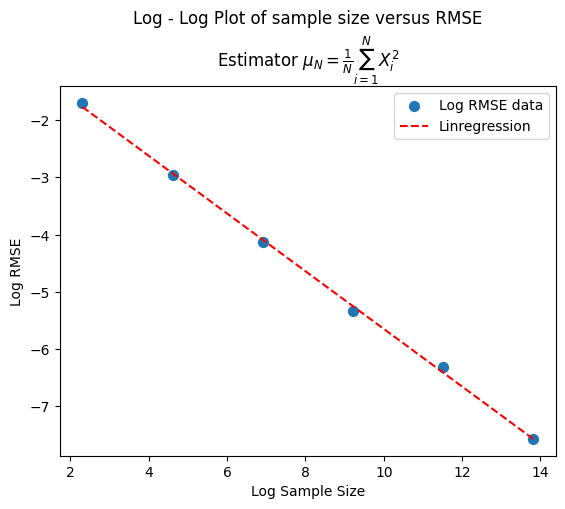

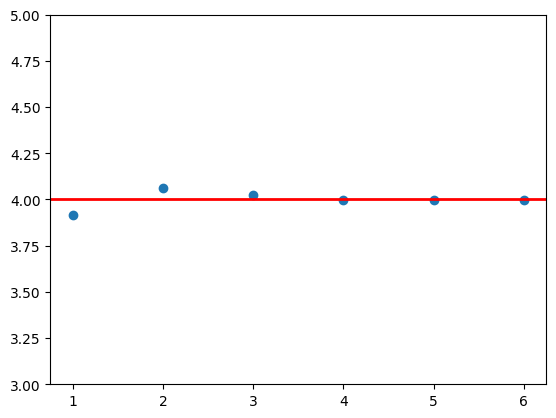

In [30]:
# Compare against theory.

# MC theory says:
# Error proportional to 1/sqrt(N)

# Get Best Fit line.
# Using estimated output data, estimate the fit.
from numpy.polynomial import Polynomial

x_data = np.log(log_sample_sizes)
y_data = np.log(estimator_rmse)
best_fit_line = Polynomial.fit(x_data, y_data, deg=1)

y_intercept, best_fit_slope = best_fit_line.convert().coef
print(f"best_fit_slope: {best_fit_slope}")

# Plot the RMSE and the best fit line.
plt.figure()
plt.scatter(x_data, y_data, s=50, label="Log RMSE data");
plt.plot(x_data, list(map(lambda x: best_fit_slope * x + y_intercept, x_data)), color="red", linestyle="--", label="Linregression");

plt.title("Log - Log Plot of sample size VS RMSE" "\n" r"Estimator $\mu_N  = \frac{1}{N} \sum_{i=1}^N X_i^2$");
plt.ylabel("Log RMSE");
plt.xlabel("Log Sample Size");
plt.legend();


# Plot the actual values compared to the mean. 
plt.figure()
x_space = [np.log10(x) for x in log_sample_sizes]
plt.scatter(x_space, estimator_mean);
plt.axhline(y=sigma ** 2, color="red", linestyle="-", linewidth=2);
# plt.xlim(0, 5)
plt.ylim(3, 5);

## Conclusion 

The conclusion here is that the unbiased estimator for $E(X^2)$, $m = \frac{1}{N}\sum_{i=1}^N X_i^2$  is  $\propto 1 / \sqrt{N}$ as expected. We verified this with a regression on the RMSE, finding the slope is $-1/2$.

# Extension 1: Antithetic Variate

Antithetic variates provide a low-cost or same-cost solution to reducing the variance of a new estimate for a desired quantity. We will see this work here for the exmaple, but it will expose that it may not produce any value to us when distributions are even functions ($f(x) = f(-x)$).

## Theory: Antithetic Variate

In the antithetic path reduces the variance of the MC simulation results with the goal of improving the rate of convergence.

https://en.wikipedia.org/wiki/Antithetic_variates

The method is as follows:

Take each sample path and with it, take an antithetic path:

\begin{align*}
    \{ \epsilon_1, \epsilon_2, \ldots, \epsilon_M \} \\
    %
    \{- \epsilon_1, - \epsilon_2, \ldots, -\epsilon_M \} \\
\end{align*}

This technique reduces the number of samples taken to generate $N$ paths.  It also reduces the variance of the sample paths. 


Let us estimate some quantity:

\begin{align*}
    \theta = E\left( h(X) \right) = E(Y)
\end{align*}

Suppose to calculate an estimate we gather two samples $Y_1, Y_2$. An **unbiased** estimator of $\theta$ is:

\begin{align*}
    \hat{\theta} = \frac{Y_1 + Y_2}{2}. 
\end{align*}

We can calculate 

\begin{align*}
    Var(\hat{\theta}) = \frac{Var(Y_1) + Var(Y_2) + 2 Cov(Y_1, Y_2)}{4}
\end{align*}

The first two terms above are always positive, while the covariance can be negative, and maximally so when $Y_1 = -Y_2$.



## Example 1

**One example here is** 

Supose $X \sim U[0,1]$ with one sample: $u = \{u_1, u_2, \ldots, u_M \}$. How would we build the antithetic sample? 

As follows:

\begin{align*}
    u' = \{1 - u_1, 1 - u_2, \ldots, 1 - u_M \}.
\end{align*}

Note that these would satisfy $u' \sim U[0, 1]$ as well.

Now suppose we want to estimate 

$$
I = \int_0^1 \frac{1}{1 + x} dx,
$$

with the exact solution $I = ln(2) \approx 0.69314$.

One way to think about this integral is expected value of $f(U)$ where $U \sim U[0,1]$ and $f(U) = \frac{1}{1 + U}$, and by the definition of expected value:

$$
    E(f(U)) = \frac{1}{1 - 0} \int_0^1 f(U) \cdot 1 \ dU = \frac{1}{1 - 0} \int_0^1 \frac{1}{1 + x} \cdot 1 \ dx
    %

$$

Suppose we then esimate $E(f(U))$ using the unbiased estimate: 

$$\hat{\theta}_A = \hat{E}_A = \frac{1}{2M} \sum_{i = 1}^{2M} \frac{1}{1 + u_i} $$

Given antitetical values $u, u'$, we would estimate 

$$\hat{\theta}_B = \hat{E}_B =  \frac{1}{2M} \left( \sum_{i = 1}^{M} \frac{1}{1 + u_i} + \sum_{i = 1}^{M} \frac{1}{1 + u_i'} \right)$$

Why the $2M$ for calculation $A$? because to compare equal sized samples we have to collect twice as many direct samples for $u$ versus if we use the antithetic sampling, which is free, because we just use what we already have an convert as $u' = 1 - u$.




## Antithetic Variate pre-Buildout

Let's write the code to support this example.

Estimates
theta_A: 0.7022025186758325
theta_Bp: 0.6924534519812481
Absolute Error
E-theta_A: 0.009055338115887213
E-theta_Bp: 0.0006937285786972058


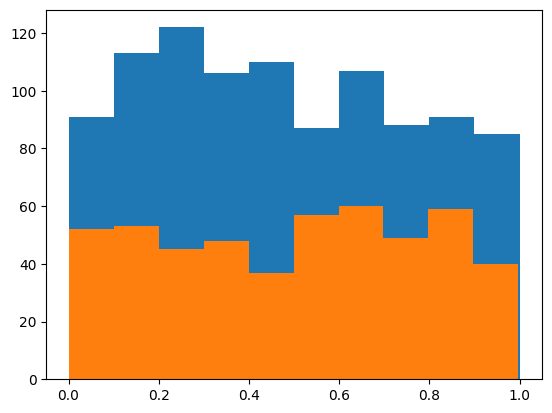

In [17]:
import numpy as np

# rng = np.random.default_rng(seed=42)

# Collect sampling and antithetic sample.
M = 500
u_A = rng.uniform(0, 1.0, 2 * M)
u_B = rng.uniform(0, 1.0, M)
u_Bp = np.concatenate((u_B, (1 - u_B)))

plt.hist(u_A);
plt.hist(u_B);
# plt.hist(u_Bp, label="antithetic");

# Build the estimates:

theta_A =  sum(1 / (1 + u_A)) / (2 * M)
theta_Bp = sum(1 / (1 + u_Bp)) / (2 * M)

exact_soln = np.log(2)
print("Estimates")
print(f"theta_A: {theta_A}")
print(f"theta_Bp: {theta_Bp}")
print("Absolute Error")
print(f"E-theta_A: {abs(theta_A - exact_soln)}")
print(f"E-theta_Bp: {abs(theta_Bp - exact_soln)}")

## Build the Antithetic Estimator

Let's build an antithetic variate for our problem.

Given that $X \sim N(0,2^2)$, and we are estimating $\theta = E(X^2)$ using $\hat{\theta} = \frac{1}{M} \sum_{i=1}^M X_i^2$.

Suppose we use the *biased* estimator:

$$ \hat{\theta}_A = \frac{1}{2M} \sum_{i=1}^{2M} u_i^2 $$

where 

$u = \{ u_1, u_2, \ldots, u_M, \ldots u_{2M} \}$ and $u_i \sim N(0, 2^2).$

We can build the antithetic variate as follows:

\begin{align*}
    u' &= \{ \pm u_1', \pm u_2', \ldots, \pm u_M' \}
    \Rightarrow \\[3ex]
    \hat{\theta}_B &= \frac{1}{2M} \left( \sum_{i=1}^M (u_i')^2 + \sum_{i=1}^M (-u_i')^2\right) \\[3ex]
    &= \frac{1}{2M} \left( \sum_{i=1}^M (u_i')^2 + \sum_{i=1}^M (u_i')^2\right) \\[3ex]
    &= \frac{1}{2M} \sum_{i=1}^M 2(u_i')^2 = \frac{1}{M} \sum_{i=1}^M (u_i')^2 
\end{align*}

This is not surprising because of the symmetry of $f(U) = f(-U)$. This is telling us that the antithetic variate "scales" identically to the original estimator, since both $u_i$ and $u'_i$ are equally sampled from the same distribution. We should expect to see no gain here from the antithetic variant of the estimator.




Let's write the code to support this finding. Again, we will use the mean of estimates and resample at the same sample size as before.

In [ ]:
# lets build estimator for quantity E(X^2).

# for a X~N(0, 2^2), we get 4? Var(X) = E(X^2) - E(X)^2 = E(X^2) = 4. 

# Seeding.
# rng = np.random.default_rng(seed=42)

# Distribution Params.
sigma = 2.0
true_mean = 0.0

exact_solution = sigma ** 2

# Get N numbers. 

# Time to scale up to multiple repeated draws.

# Storing data.
estimator_mean_A = []
estimator_sdev_A = []
estimator_rmse_A = []
error_abs_mean_A = []

estimator_mean_B = []
estimator_sdev_B = []
estimator_rmse_B = []
error_abs_mean_B = []

runtime_mean = []

# Executing loop.
log_sample_sizes = [10 ** i for i in range(1, 7)]
repeat_draw_size = 50 # Do half as many this time because you will double the amount drawn later.
repeat_draws = range(1, repeat_draw_size + 1)

for sample_size in log_sample_sizes:
    # Get estimator A from the same "round".
    estimator_A = []
    estimator_B = []
    error_abs_A = []
    error_abs_B = []
    runtime = []

    # Get repeated draws for this sample size.
    for draw in repeat_draws:
        time_start = time.perf_counter()

        # Draw the random numbers.
        u_A = rng.normal(loc=true_mean, scale=sigma, size=(2 * sample_size))
        u_B = rng.normal(loc=true_mean, scale=sigma, size=sample_size)
        u_Bp = np.concatenate((u_B, -u_B)) # Now you have the same number of samples in both estimators.
        
        # Make the estimators.
        mu_A = sum(u_A ** 2) / (2 * sample_size)
        mu_B = sum(u_Bp ** 2) / (2 * sample_size)
        estimator_A.append(mu_A)
        estimator_B.append(mu_B)
        error_abs_A.append(abs(mu_A - exact_solution))
        error_abs_B.append(abs(mu_B - exact_solution))

        time_end = time.perf_counter()
        runtime.append(time_end)
    
    # Calculate mean and error of estimates at this sample size.
    estimator_mean_A.append(sum(estimator_A) / repeat_draw_size)
    estimator_mean_B.append(sum(estimator_B) / repeat_draw_size)
    error_abs_mean_A.append(sum(error_abs_A) / repeat_draw_size)
    error_abs_mean_B.append(sum(error_abs_B) / repeat_draw_size)
    runtime_mean.append(sum(runtime) / repeat_draw_size)

    # Calculate Stand Dev and RMSE of estimates.
    estimator_sdev_A_ = np.sqrt(sum([(x - estimator_mean_A[-1]) ** 2 for x in estimator_A]) / (repeat_draw_size - 1))
    estimator_sdev_B_ = np.sqrt(sum([(x - estimator_mean_B[-1]) ** 2 for x in estimator_B]) / (repeat_draw_size - 1))
    estimator_sdev_A.append(estimator_sdev_A_)
    estimator_sdev_B.append(estimator_sdev_B_)

    estimator_rmse_A_ = np.sqrt(sum([(exact_solution - y_hat) ** 2 for y_hat in estimator_A]) / (repeat_draw_size))
    estimator_rmse_B_ = np.sqrt(sum([(exact_solution - y_hat) ** 2 for y_hat in estimator_B]) / (repeat_draw_size))
    estimator_rmse_A.append(estimator_rmse_A_)
    estimator_rmse_B.append(estimator_rmse_B_)


best_fit_slope_A: -0.4894980802731193
best_fit_slope_B: -0.5014023868457128


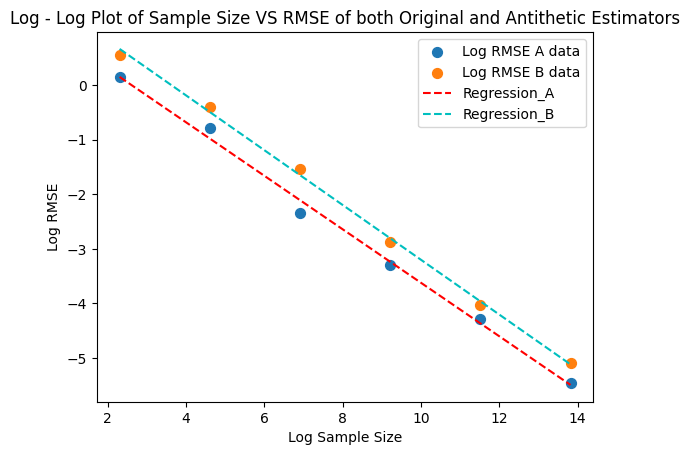

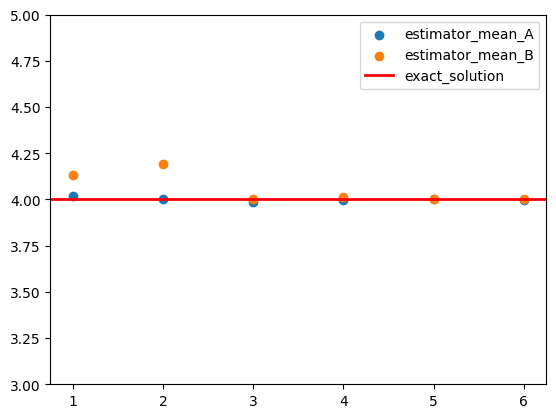

In [86]:
# Compare against theory.
from numpy.polynomial import Polynomial

x_data = np.log(log_sample_sizes)
y_data_A = np.log(estimator_rmse_A)
y_data_B = np.log(estimator_rmse_B)

# Best fit lines.
best_fit_line_A = Polynomial.fit(x_data, y_data_A, deg=1)
best_fit_line_B = Polynomial.fit(x_data, y_data_B, deg=1)
y_intercept_A, best_fit_slope_A = best_fit_line_A.convert().coef
y_intercept_B, best_fit_slope_B = best_fit_line_B.convert().coef
print(f"best_fit_slope_A: {best_fit_slope_A}")
print(f"best_fit_slope_B: {best_fit_slope_B}")

plt.figure()
plt.scatter(x_data, y_data_A, s=50, label="Log RMSE A data");
plt.scatter(x_data, y_data_B, s=50, label="Log RMSE B data");
plt.plot(x_data, list(map(lambda x: best_fit_slope_A * x + y_intercept_A, x_data)), color="red", linestyle="--", label="Regression_A");
plt.plot(x_data, list(map(lambda x: best_fit_slope_B * x + y_intercept_B, x_data)), color="c", linestyle="--", label="Regression_B");

plt.title("Log - Log Plot of Sample Size VS RMSE of both Original and Antithetic Estimators");
plt.ylabel("Log RMSE");
plt.xlabel("Log Sample Size");
plt.legend();
plt.legend();

# Plot the actual values compared to the mean. 
plt.figure()
x_space = [np.log10(x) for x in log_sample_sizes]
plt.scatter(x_space, estimator_mean_A, label="estimator_mean_A");
plt.scatter(x_space, estimator_mean_B, label="estimator_mean_B");
plt.axhline(y=exact_solution, color="red", linestyle="-", linewidth=2, label="exact_solution");
# plt.xlim(0, 5)
plt.ylim(3, 5);
plt.legend();


## Conclusion

We explored the antithetic variate of the estimator, and we found that there is no improvement in our accuracy because the quantity we are estimating takes the shape of an even function $f(U) = f(-U)$. There is a marginal improvement in performance, since we require fewer samples drawn, but this is also at the mild expense of accuracy. As shown in the first plot, both RMSE log ression are parallel, with the regression for the antithetic variate estimator being higher. This is because we essentially have half as many values drawn for the antithetic variate estimator compared to the original estimator.

# Extension 2: Control Variates

We explore the use of control variates to reduce get a better esimate.

## Theory: Control Variates

https://en.wikipedia.org/wiki/Control_variates

Used in variance reduction for Monte Carlo methods. We can use information about errors of **known** estimates of **known** quantities to reduce the error of an **estimate** of an **unknown quantity**.

Given parameter of interest (unknown/UK) $\mu$, suppose there is a statistic $m$ $s.t.$ $E(m) = \mu$. 
This $m$ is then an **unbiased estimator** of $\mu$. 

We want have already or can calculate another statistic $t$ so that $E(t) = \tau$ is a **known value**. These are the knowns. 

It follows that: 

$$m^* = m + c(t - \tau)$$

is an **unbiased estimator** for $\mu$ FOR ANY CHOICE OF $c$. 

To see this:

\begin{align*}
    E(m^*) &= E(m + c(t - \tau)) = E(m + c(t - \tau)) \\[2ex]
    &= E(m) + cE(t - \tau) = E(m) + c(E(t) - E(\tau)) \\[2ex]
    &= E(m) + c(0) = E(m) = \mu
\end{align*}

The variance of this estimator is derived as:

\begin{align*}
    Var(m^*) &= Var(m + c(t - \tau)) \\[2ex]
    &= Var(m) + Var(c(t - \tau)) + Cov(m, c(t - \tau)) \\[2ex]
    &= Var(m) + c^2 Var(t - \tau) + 2c \cdot Cov(m, t - \tau) \\[2ex]
    &= Var(m) + c^2 Var(t) + 2c \cdot Cov(m, t) 
\end{align*}

We would like to optimize/minimize this so assuming differentiability,

\begin{align*}
    \frac{\partial (Var(m^*))}{\partial c} &= 2c Var(t) + 2c Cov(m, t) = 0 \\[2ex]
    \Rightarrow c_{optimal} &= - \frac{Cov(m, t)}{Var(t)}
\end{align*}

This $c_{optimal}$ will minimize the variance of $m^*$. Replacing into the previous:

\begin{align*}
    Var(m^*) &= Var(m) + \frac{Cov(m, t)^2}{Var(t)^2}Var(t) - 2 \frac{Cov(m, t)}{Var(t)} Cov(m, t) \\[3ex]
    &= Var(m) + \frac{Cov(m, t)^2}{Var(t)} - 2 \frac{Cov(m, t)^2}{Var(t)} \\[3ex]
    &= Var(m) - \frac{Cov(m, t)^2}{Var(t)} = Var(m) \left( 1 - \frac{Cov(m, t)^2}{Var(t)Var(m)} \right) \\[3ex]
    &= Var(m) \left( 1 - \left(\frac{Cov(m, t)}{ \sqrt{ Var(t)Var(m) }} \right)^2  \right) \\[3ex]
    &= Var(m) (1 - \rho^2(m, t))
\end{align*}

The unknowns here are $Cov(m,t), Var(t), \text{ and } \rho(m,t)$. Each is estimated across Monte Carlo replicates. This technique is also called **regression sampling**. 

## Example 2

**One Example here is**  again using the same quantity of interest as before.

Estimate this quantity using Monte Carlo integration (MC integration). 
$$
I = \int_{0}^1 \frac{1}{1 + x} \ dx
$$

with the exact solution $I = ln(2) \approx 0.69314$.


We may consider this result as the mean value of RV $f(U) = \frac{1}{1 + U}$ where $U \sim U[0,1]$ and $E(f(U)) = \frac{1}{1 - 0} \int_{0}^1 \frac{1}{1 + x} \cdot 1 \ dx = I$.

If we take a sample $\vec{u}_N = \{ u_1, u_2, \ldots, u_N \}$,
we can estimate $I$ using the unbiased estimator of $E(f(U)) = \mu$:

$$
    I \approx \frac{1}{N} \sum_{i=1}^N f(u_i) = \frac{1}{N} \sum_{i=1}^N \frac{1}{1 + u_i} = m
$$

So far nothing has changed from before. 

Next we want a control variate with a known expected value. We can think of a control variate $g(U) = 1 + U$, which is correlated with $f(U)$, and we calculate its mean as: 

\begin{align*}
    E(g(U)) &= \frac{1}{1 - 0}\int_{0}^1 (u + 1) \cdot 1 \ du \\[2ex]
    %
    &= \left. \frac{u^2}{2} + u \right\rvert_0^1 = \frac{3}{2} = \tau
\end{align*}

Now we can build the new unbiased estimator for $\mu$:

\begin{align*}
    m^* &= m + c ( t - \tau) = m + c(t - 3/2) \\[2ex]
\end{align*}

We already have $m$ and $m^*$ as unbiased estimators of $\mu$, but we need $t$, the unbiased estimator of $E(g(U))$.
Observe putting $t$ as:

\begin{align*}
    t = \frac{1}{N} \sum_{i=1}^N g(u_i) \Rightarrow E(t) = \frac{1}{N} \sum_{i=1}^N E(g(u_i)) =  \frac{1}{N} \sum_{i=1}^N E(g(U)) = E(g(U))
\end{align*}.

This is the unbiased estimator for $E(g(U))$. We proceed to write:

\begin{align*}
    E(g(U)) &= \frac{1}{1 - 0}\int_{0}^1 (u + 1) \cdot 1 \ du \approx \frac{1}{N} \sum_{i=1}^N g(u_i) = \frac{1}{N} \sum_{i=1}^N 1 + u_i = t \\[3ex]
    &\Rightarrow \\[2ex]
    \mu = E(m^*) &= \frac{1}{N} \sum_{i=1}^N f(u_i) + c \left( \frac{1}{N} \sum_{i=1}^N g(u_i) - \tau \right)
\end{align*}

The next objective is to find $c_{optimal}$, and as the theory outlines, we will need $Cov(m,t)$ and $Var(t)$. We can attempt to derive it or estimate it empirically using a sampling strategy. See below for how to do it through estimation. For this case, we can calculate it from theory exactly as follows:

\begin{align*}
    c_{optimal} &= -\frac{Cov(m, t)}{Var(t)} =  - \frac{E(m \cdot t) - E(m)E(t)}{E(t^2) - E^2(t)} 
    = - \frac{E(f(U) \cdot g(U)) - E(f(U))E(g(U))}{E(g^2(U)) - E^2(g(U))} \\[3ex]
    E(f(U) \cdot g(U)) &= \int_0^1 \frac{1}{1 + U} \cdot (U + 1) \ dU = 1, \ 
    E(f(U)) = \int_0^1 \frac{1}{1 + U} \ dU = ln(2),  \\[3ex]
    E(g(U)) &= \int_0^1 1 + U \ dU = 3/2, \ E(g^2(U)) = \int_0^1 (1 + U)^2 \ dU = 7/3 \\[3ex]
    \Rightarrow c_{optimal} &= - \frac{1 - ln(2) \cdot 3/2}{7/3 - (3/2)^2} \approx 0.47664925
\end{align*}

This leads us to:

\begin{align*}
    \mu \approx m^* = \frac{1}{N} \sum_{i=1}^N f(u_i) + 0.47664925 \left( \frac{1}{N} \sum_{i=1}^N g(u_i) - 3/2 \right)
\end{align*}

Suppose now we compare now the original estimator $m$ and the controled variate estimator $m^*$.


## Control Variate pre-buildout

Let's write the code to support this exmaple.

In [108]:
# Buildout.

# Seeding.
# rng = np.random.default_rng(seed=42)

repeat_draws = 1000
sample_size = 50
tau = 3 / 2

exact_solution = np.log(2)

# Build estimates.
U = rng.uniform(0, 1, sample_size)
f_U = 1 / (1 + U)
g_U = 1 + U

m = np.mean(f_U)
t = np.mean(g_U)

# Get c_opt.
# This is now done with theory.
c_opt = -1 * (1 - np.log(2) * 3 / 2) / (7 / 3 - (3 / 2) ** 2)
print(f"c_opt: {c_opt}")

# Control variate estimate.
m_star = m + c_opt * (t - tau)

error_m_star = abs(m_star - exact_solution)
error_m = abs(m - exact_solution)

print(f"error_m: {error_m}")
print(f"error_m_star: {error_m_star}")



c_opt: 0.47664925007901365
error_m: 0.017790613859393067
error_m_star: 0.005198130436566806


## Estimating $c_{optimal}$ 


If we did not readily have $Cov(m,t)$ and $Var(t)$ to form $c_{optimal}$, we can estimate them as follows:

\begin{align*}
    Cov(m, t) \to \widehat{Cov}(m,t) = \frac{1}{M-1} \sum_{i=1}^M (m_i - \bar{m})(t_i - \bar{t})\\[2ex]
    Var(t) \to \widehat{Var}(t) = \frac{1}{M-1} \sum_{i=1}^M (t_i - \bar{t})^2
\end{align*}

We can calculate these by taking multiple samples of $U[0,1]$ then calculating $\{g(u_i)\}$ and $\{f(u_i)\}$. This leads to the estimates:

```
cov_m_t: 0.0007558546372138775
var_t: 0.0015662736964536417
c_opt: 0.4825814536279861
exact c_opt: 0.47664925007901365
```

This leads us to:

\begin{align*}
    \mu \approx m^* = \frac{1}{N} \sum_{i=1}^N f(u_i) +  0.482581 \left( \frac{1}{N} \sum_{i=1}^N g(u_i) - 3/2 \right)
\end{align*}

Suppose now we compare now the original estimator $m$ and the controled variate estimator $m^*$.


This leads use to the following values:

```
N: 1000
m: 0.7192092315840032
m_star: 0.6959789346777737
exact_answer: 0.6931471805599453
var_m: 0.0003614059274141569
var_m_star: 1.251236692141345e-05
Rel. Error m: 0.03759959176780346
Rel. Error m_star 0.004085357622807983
```

You can see for the SAME COST as the original MC estimate, there is a controled variate unbiased estimate with a much lower variance.


In [109]:
## Estimating c_opt numerically.

import numpy as np

# rng = np.random.default_rng(seed=42)

# Collect Sample.
## Requires repeated draws to estimate c_opt
repeat_draws = 1000
sample_size = 50
f_U = []
g_U = []
t = []
m = []
for i in range(repeat_draws):

    U = rng.uniform(0, 1, sample_size)

    f_U = 1 / (1 + U)
    g_U = 1 + U

    t_ = np.mean(g_U)
    m_ = np.mean(f_U)
    t.append(t_)

    m.append(m_)

cov_m_t = -1 * sum((m - np.mean(m)) * (t - np.mean(t))) / (repeat_draws - 1)
print(f"cov_m_t: {cov_m_t}")

var_t = sum((t - np.mean(t)) ** 2) / (repeat_draws - 1)
print(f"var_t: {var_t}")

var_m = sum((m - np.mean(m)) ** 2) / (repeat_draws - 1)
print(f"var_m: {var_m}")

c_opt = cov_m_t / var_t
print(f"c_opt: {c_opt}")

cov_m_t: 0.0007863765658719064
var_t: 0.001642720080508233
var_m: 0.00038904807100862093
c_opt: 0.4787039345307164


## Build the Control Variate Estimator

Let's build the control variate stimator for our problem.

Given that $X \sim N(0,2^2)$, and we are estimating 
$\mu = E(X^2)$ using  $m = \frac{1}{M}\sum_{i=1}^M X_i^2$, which is an unbiased estimator of the former quantity. 

We would like to find a control variate estimator. One key is to develop something that is very similar to our own quantity of interest. Put $f(U) = U^2$, where $U \sim N(0, 2^2)$. One possible choice is $g(U) = U$. This has a very close relationship with $f(U)$, which can hopefully reduce some of our estimation variance while leading us to an unbiased estimator. 

To that end, we calculate calculate $\tau$ as:

$$
\tau = E(g(U)) = E(U) = 0,
$$

Since $U$ is normally distributed with mean 0. This may not be bad, but let's see about setting up the new unbiased estimator:

\begin{align*}
    m^* &= m + c (t - \tau) \\[1ex]
    t &= \frac{1}{N} \sum_{i=1}^N X_i \\[4ex]
    c_{optimal} &= \ -\frac{Cov(m, t)}{Var(t)} \\[3ex]
    Cov(m, t) &= E(m t) - E(m)E(t) \\
    &= E(f(U)g(U)) - E(f(U))E(g(U)) \\
    &= E(U^3) - E(U^2)E(U) = 0 \\
    \Rightarrow m^* = m
\end{align*}

The last equality is from the even symmetry of the normal distribution. The result is that using this control variate gives us nothing! We will have to find something else. Note: Any $g(U) = U^{2k + 1}$ will yield the same result, so if we try a similar approach, we should stick to at least even powers of $U$. See the section on "Moments of a Normal Distribution" for more details.

What if we try $g(U) = U^2$? This goes against the strategy of using a known estimate to get an edge on an unkonwn estimate. In this case, we would be trying the SAME ONE! Let's carry out the calculation and see what happens. 

\begin{align*}
    \tau &= E(g(U)) = E(U^2) = \mu \\[1ex]
    m^* &= m + c (t - \tau) \\[1ex]
    t &= \frac{1}{N} \sum_{i=1}^N X^2_i = m \\[4ex]
    c_{optimal} &= \ -\frac{Cov(m, t)}{Var(t)} \\[3ex]
    Cov(m, t) &= E(m t) - E(m)E(t) \\
    &= E(f(U)g(U)) - E(f(U))E(g(U)) \\
    &= E(U^4) - E(U^2)E(U^2) = ? \\
    \text{Observe:}\\
    var(t) &= E(U^4) - E^2(U^2) \Rightarrow c_{optimal} = -1 \\
    \Rightarrow m^* &= m - 1 \cdot (m - \mu) = \mu
\end{align*}

Which is essentially saying the best estimate is the actual value we are trying to estimate.

What if we try $g(U) = U^4$? Again, we would have to get $E(U^4)$, which would presumably be just as difficult as the thing we're to estimate. We will proceed anyway.

\begin{align*}
    \tau &= E(g(U)) = E(U^4) \\[1ex]
    m^* &= m + c (t - \tau) \\[1ex]
    t &= \frac{1}{N} \sum_{i=1}^N X^4_i\\[4ex]
    c_{optimal} &= \ -\frac{Cov(m, t)}{Var(t)} \\[3ex]
    Cov(m, t) &= E(m t) - E(m)E(t) \\
    &= E(f(U)g(U)) - E(f(U))E(g(U)) \\
    &= E(U^6) - E(U^2)E(U^4) \\
    var(t) &= E(U^8) - E^2(U^4)\\
\end{align*}

This is where we face the challenge of unraveling other estimates that are just as unkonwn as the one we want. We can find the exact values by using the moment generating function. Using the work in the section "Moments of a Normal Distribution $N(0, \sigma^2)$", we can write:

\begin{align*}
    E(U^2) &= \frac{\sigma^{2}(2)!}{2 \cdot 1!} = \sigma^2, \\
    E(U^4) &= \frac{\sigma^{4}(4)!}{2^2 \cdot 2!} = 3\sigma^4, \\
    E(U^6) &= \frac{\sigma^{6}(6)!}{2^3 \cdot 3!} = 15\sigma^6, \\
    E(U^8) &= \frac{\sigma^{8}(8)!}{2^4 \cdot 4!} = 105\sigma^8, \\
    \Rightarrow\\
    &\boxed{c_{optimal} = -\frac{15\sigma^6 - \sigma^2 (3\sigma^4)}{105\sigma^8 - (3\sigma^4)^2} = \frac{-1}{8 \sigma^2}}
\end{align*}

We can build the control variates estimator as:

$$
    \mu \approx m^* = 
        \frac{1}{N}\sum_{i=1}^N X_i^2 
        - \frac{1}{8 \sigma^2}\left( \frac{1}{N} \sum_{i=1}^N X^4_i - 3\sigma^4 \right)
$$

We implement the code to support this theory. Again, we will use the means of repeated sampling at the same sample size as we did in the first section.

In [117]:
# Build the estimator for E(X^2).  

# X ~ N(0, 2^2) exact solution = 2^2 = 4

# Seeding
# rng = np.random.default_rng(seed=42)

# Distribution Params
true_mean = 0.0
sigma = 2.0

exact_solution = sigma ** 2
tau = 3 * sigma ** 4
c_opt = -1 / (8 * sigma ** 2)

# Get N numbers.

# Storing Data.
estimator_mean_o = []
estimator_sdev_o = []
estimator_rmse_o = []
error_abs_mean_o = []

estimator_mean_cv = []
estimator_sdev_cv = []
estimator_rmse_cv = []
error_abs_mean_cv = []

runtime_mean = []

# Executing Loop.
log_sample_sizes = [10 ** i for i in range(1, 7)] # This is N_k in the theory.
repeat_draw_size = 100 # This is 'I' in the theory.
repeat_draws = range(1, repeat_draw_size + 1)

for sample_size in log_sample_sizes:
    # o = original
    # CV = control variate
    # Storing estimators.
    estimator_o = []
    estimator_cv = []
    error_abs_o = []
    error_abs_cv = []
    runtime = []

    # Get repeated draws at this sample size:
    for draw in repeat_draws:
        time_start = time.perf_counter()

        # Draw the random numbers.
        U = rng.normal(loc=true_mean, scale=sigma, size=sample_size)

        # Build the estimates.
        f_U = U ** 2
        g_U = U ** 4

        m = np.mean(f_U)
        t = np.mean(g_U)

        # Get c_opt
        # c_opt = 1 / (8 * sigma ** 2)

        m_star = m + c_opt * (t - tau)

        estimator_o.append(m)
        estimator_cv.append(m_star)
        error_abs_o.append(abs(m - exact_solution))
        error_abs_cv.append(abs(m_star - exact_solution))

        time_end = time.perf_counter()
        runtime.append(time_end)

    # Calculate mean and error of estimates at this sample size across the draws.
    estimator_mean_o.append(sum(estimator_o) / repeat_draw_size)
    estimator_mean_cv.append(sum(estimator_cv) / repeat_draw_size)
    error_abs_mean_o.append(sum(error_abs_o) / repeat_draw_size)
    error_abs_mean_cv.append(sum(error_abs_cv) / repeat_draw_size)
    runtime_mean.append(sum(runtime) / repeat_draw_size)

    # Calculate the standard dev and RMSE of the estimates.
    estimator_sdev_o_ = np.sqrt(sum([(x - estimator_mean_o[-1]) ** 2 for x in estimator_o]) / (repeat_draw_size - 1))
    estimator_sdev_cv_ = np.sqrt(sum([(x - estimator_mean_cv[-1]) ** 2 for x in estimator_cv]) / (repeat_draw_size - 1))
    estimator_sdev_o.append(estimator_sdev_o_)
    estimator_sdev_cv.append(estimator_sdev_cv_)

    estimator_rmse_o_ = np.sqrt(sum([(y_hat - exact_solution) ** 2 for y_hat in estimator_o]) / (repeat_draw_size))
    estimator_rmse_cv_ = np.sqrt(sum([(y_hat - exact_solution) ** 2 for y_hat in estimator_cv]) / (repeat_draw_size))
    estimator_rmse_o.append(estimator_rmse_o_)
    estimator_rmse_cv.append(estimator_rmse_cv_)

best_fit_slope_o: -0.5032315100239645
best_fit_slope_cv: -0.511294894448242


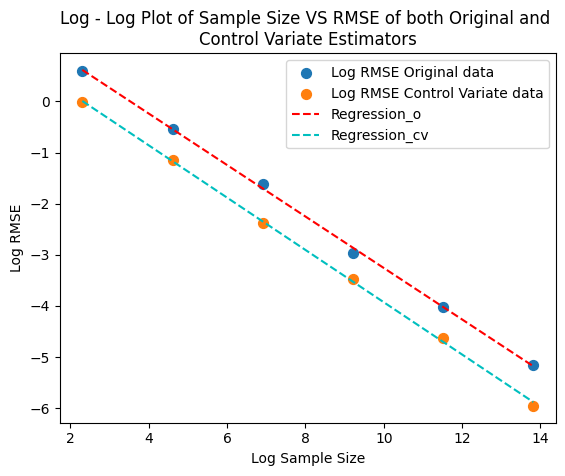

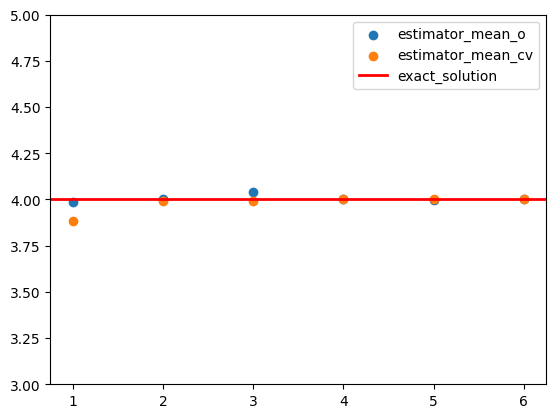

In [120]:
# Let's Plot and compare against theory.

from numpy.polynomial import Polynomial

x_data = np.log(log_sample_sizes)
y_data_o = np.log(estimator_rmse_o)
y_data_cv = np.log(estimator_rmse_cv)


# Best fit lines.
best_fit_line_o = Polynomial.fit(x_data, y_data_o, deg=1)
best_fit_line_cv = Polynomial.fit(x_data, y_data_cv, deg=1)
y_intercept_o, best_fit_slope_o = best_fit_line_o.convert().coef
y_intercept_cv, best_fit_slope_cv = best_fit_line_cv.convert().coef
print(f"best_fit_slope_o: {best_fit_slope_o}")
print(f"best_fit_slope_cv: {best_fit_slope_cv}")

plt.figure();
plt.scatter(x_data, y_data_o, s=50, label="Log RMSE Original data");
plt.scatter(x_data, y_data_cv, s=50, label="Log RMSE Control Variate data");
plt.plot(x_data, list(map(lambda x: best_fit_slope_o * x + y_intercept_o, x_data)), color="red", linestyle="--", label="Regression_o");
plt.plot(x_data, list(map(lambda x: best_fit_slope_cv * x + y_intercept_cv, x_data)), color="c", linestyle="--", label="Regression_cv");

plt.title("Log - Log Plot of Sample Size VS RMSE of both Original and \nControl Variate Estimators");
plt.ylabel("Log RMSE");
plt.xlabel("Log Sample Size");
plt.legend();
plt.legend();

# Plot the actual values compared to the mean. 
plt.figure()
x_space = [np.log10(x) for x in log_sample_sizes]
plt.scatter(x_space, estimator_mean_o, label="estimator_mean_o");
plt.scatter(x_space, estimator_mean_cv, label="estimator_mean_cv");
plt.axhline(y=exact_solution, color="red", linestyle="-", linewidth=2, label="exact_solution");
# plt.xlim(0, 5)
plt.ylim(3, 5);
plt.legend();

In [ ]:
# buffer. 

## Moments of a Normal Distribuiton $N(0, \sigma^2)$

To find powers of expected values of a RV $X$, $E(X^n)$, we can use the moment generating function give by:

\begin{align*}
    M_X(t) = E(e^{tX})
\end{align*}

We focus on applying this to $X \sim N(0, \sigma^2)$. The moment generating function is found as follows:

\begin{align*}
    M_X(t) &= \int_{\mathbb{R}} e^{tx} \frac{1}{\sqrt{2 \pi \sigma^2}} e^{-\frac{(x - 0)^2}{2 \sigma^2}} \ dx 
    = \int_{\mathbb{R}} \frac{1}{\sqrt{2 \pi \sigma^2}} e^{- \frac{(x - 2 \sigma^2 t x)}{2 \sigma^2}} \ dx \\[3ex]
    %
    \text{completing the square} \Rightarrow \\[3ex]
    M_X(t) &= \int_{\mathbb{R}} \frac{1}{\sqrt{2 \pi \sigma^2}} e^{- \frac{(x^2 - 2 \sigma^2 t x + \sigma^2t^2 - \sigma^2t^2)}{2 \sigma^2}} \ dx 
    = \int_{\mathbb{R}} \frac{1}{\sqrt{2 \pi \sigma^2}} e^{- \frac{(x - \sigma^2 t)^2 - \sigma^4 t^2}{2 \sigma^2}} \ dx \\[3ex]
    %
    &= e^{\frac{\sigma^2 t^2}{2}} \int_{\mathbb{R}} \frac{1}{\sqrt{2 \pi \sigma^2}} e^{- \frac{(x - \sigma^2 t)^2 }{2 \sigma^2}} \ dx  = e^{\frac{\sigma^2 t^2}{2}} \cdot 1.
\end{align*}

Now that we have the moment generating function, we would like to get $E(X^n)$. We can expand both sides  of $e^{\frac{\sigma^2 t^2}{2}} = E(e^{tX})$ with respect to $t$ so that:

\begin{align*}
    e^{\frac{\sigma^2 t^2}{2}} &= 1 + \frac{\sigma^2 t^2}{2} + \frac{\sigma^4 t^4}{2^2 2!} 
    + \frac{\sigma^6 t^6}{2^3 3!} + \cdots + \frac{\sigma^{2k} t^{2k}}{2^k k!} + \ldots \\[2ex]
    %
    E(e^{tX}) &= E \left(
        1 + tX + \frac{(tX)^2}{2!} + \frac{(tX)^3}{3!} + \ldots +  \frac{(tX)^j}{j!} + \ldots \right) \\[2ex]
    %
    &= E(1) + tE(X) + \frac{t^2}{2!}E(X^2) + \frac{t^3}{3!}E(X^3) + \ldots +  \frac{t^j}{j!}E(X^j) + \ldots \\[2ex]
    \text{Matching coefficients of powers of $t$, we get }\\[2ex]
    %
    E(X^{2k + 1}) &= 0, \ \ k = 0, 1, 2, 3, \ldots \\[2ex]
    %
    E(X^{2k}) &= \frac{\sigma^{2k}(2k)!}{2^k k!}, \ \ k = 0, 1, 2, 3, \ldots \\[2ex]
\end{align*}

These are the moments for a normal distribution $N(0, \sigma^2)$.

